# 📈 Khám Phá Mối Tương Quan: Đặc Tính Tiêu Đề (Title Features) & User Engagement
## 🎯 Tiên Đoán Sức Hút Video & Livestream Dựa Trên Các Yếu Tố Quan Sát Được Từ Tiêu Đề (Views, Likes, Comments, Sentiment)

---
### 🎯 Mục tiêu nghiên cứu:
1. **Trích xuất đặc tính Tiêu đề (Title Feature Engineering)**: Bóc tách các tín hiệu định lượng từ tiêu đề video như: độ dài ký tự/từ, tỷ lệ chữ hoa (`Caps Ratio`), dấu hỏi `?`, dấu than `!`, con số, thẻ ngoặc `[ ]`, và các từ kích thích (`Power Words`).
2. **Phân tích Ma trận Tương quan (Correlation Analysis)**: Đo lường độ tương quan tuyến tính (**Pearson**) và phi tuyến tính (**Spearman Rank**) giữa các đặc tính tiêu đề với `Views`, `Likes`, `Comments`, `Like-to-View Ratio`, và `Comment-to-View Ratio`.
3. **Kiểm định Phân bố & So sánh Nhóm (Group Comparison)**: Đo lường sự khác biệt về lượng View/Like giữa các nhóm có/không có dấu hỏi, dấu than, con số cụ thể qua Box Plot & T-Test.
4. **Phân tích Sắc thái Cảm xúc & Tương tác Bình luận (Sentiment & Comment Engagement)**: Đánh giá mối liên hệ giữa tiêu đề và mức độ phản hồi cảm xúc (Positive, Neutral, Negative) từ tập 5,000 bình luận.
5. **Mô hình Hồi quy & Đánh giá Tầm quan trọng Đặc trưng (Feature Importance)**: Sử dụng **Random Forest Regressor** để xác định đặc tính tiêu đề nào có sức mạnh tiên đoán mức độ tương tác cao nhất.

In [1]:
# 1. Khai báo thư viện phân tích & thiết lập giao diện đồ thị thẩm mỹ
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Thiết lập giao diện đồ thị hiện đại & sắc nét
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

print('✅ Đã nạp thành công các thư viện phân tích dữ liệu & Machine Learning!')

✅ Đã nạp thành công các thư viện phân tích dữ liệu & Machine Learning!


## 📂 1. Nạp & Khám Phá 2 Tập Dữ Liệu Thực Nghiệm
1. **Tập Video Metadata (`kaggle_channel_meta.csv`)**: 316 videos chứa đầy đủ các chỉ số tương tác chính xác: `view_count`, `like_count`, `comment_count`, `duration_sec`, `video_title`.
2. **Tập Comment & Sentiment (`youtube_comment_sentiment_sample.csv`)**: 5,000 mẫu bình luận kèm tiêu đề video, sắc thái cảm xúc (`Positive`, `Neutral`, `Negative`), `Likes`, `Replies`.

In [2]:
# 2. Nạp dữ liệu từ thư mục data & Chuẩn hóa kiểu dữ liệu
meta_path = '../data/kaggle_channel_meta.csv' if os.path.exists('../data/kaggle_channel_meta.csv') else 'data/kaggle_channel_meta.csv'
sent_path = '../data/youtube_comment_sentiment_sample.csv' if os.path.exists('../data/youtube_comment_sentiment_sample.csv') else 'data/youtube_comment_sentiment_sample.csv'

df_meta = pd.read_csv(meta_path)
df_sent = pd.read_csv(sent_path)

# Chuẩn hóa kiểu dữ liệu số cho df_meta để tránh lỗi kiểu chuỗi / rỗng
for col in ['view_count', 'like_count', 'comment_count', 'duration_sec']:
    df_meta[col] = pd.to_numeric(df_meta[col], errors='coerce').fillna(0)

# Chuẩn hóa dữ liệu comment sentiment
df_sent['Likes'] = pd.to_numeric(df_sent['Likes'], errors='coerce').fillna(0)
df_sent['Replies'] = pd.to_numeric(df_sent['Replies'], errors='coerce').fillna(0)
df_sent = df_sent[df_sent['Sentiment'].isin(['Positive', 'Neutral', 'Negative'])].copy()

print(f'📊 Tập Video Metadata : {df_meta.shape[0]} dòng x {df_meta.shape[1]} cột')
print(f'📊 Tập Comment Sentiment: {df_sent.shape[0]} dòng x {df_sent.shape[1]} cột')

# Hiển thị mẫu dữ liệu Video Metadata
df_meta[['video_title', 'view_count', 'like_count', 'comment_count', 'duration_sec']].head(4)

📊 Tập Video Metadata : 316 dòng x 20 cột
📊 Tập Comment Sentiment: 4995 dòng x 12 cột


,video_title,view_count,like_count,comment_count,duration_sec
0,Snapshots: Exploring Shifterator with Kaggle N...,2650,84,5,306
1,"Snapshots: Datasets, Tasks, and Animal Crossin...",4149,97,1,319
2,TPUs: AlphaGo to Speech Recognition | Kaggle,2063,52,1,436
3,Getting Curious: What it takes to build a TPU ...,637,28,0,438


## 🛠️ 2. Kỹ Thuật Trích Xuất Đặc Tính Tiêu Đề (Title Feature Engineering)
Chúng ta trích xuất **9 đặc tính quan sát được từ Tiêu đề (Observable Title Features)** và các tỷ lệ tương tác mục tiêu:

| Nhóm Đặc Tính | Tên Cột | Ý Nghĩa / Giả Thuyết Đo Lường |
| :--- | :--- | :--- |
| **Kích thước** | `title_char_length` | Tổng số ký tự trong tiêu đề (quá ngắn hay quá dài có ảnh hưởng CTR?) |
| **Kích thước** | `title_word_count` | Tổng số từ trong tiêu đề |
| **Hình thức** | `caps_ratio` | Tỷ lệ chữ IN HOA (chỉ báo giật gân / Clickbait / Urgency) |
| **Ký tự đặc biệt** | `has_question` | Chứa dấu hỏi `?` (Kích thích sự tò mò / Curiosity Gap) |
| **Ký tự đặc biệt** | `has_exclamation` | Chứa dấu than `!` (Biểu thị cảm xúc cao / High Arousal) |
| **Nội dung** | `has_number` | Chứa con số cụ thể (VD: 24h, Top 10, 2025, 100 Days -> tăng tính cụ thể) |
| **Cấu trúc** | `has_brackets` | Chứa thẻ ngoặc `[ ]` hoặc `( )` (thường chỉ Series / Episode / Topic) |
| **Cấu trúc** | `has_separator` | Chứa ký tự phân cách `\|` hoặc `-` (thường dùng phân tách Brand & Title) |
| **Từ kích thích** | `power_word_count` | Số lượng từ khóa thu hút (`How to`, `Guide`, `Best`, `Live`, `Free`, `Secret`...) |
| **Mục tiêu tương tác** | `like_rate_%` | Tỷ lệ $\frac{\text{Likes}}{\text{Views}} \times 100$ (Độ hài lòng người xem) |
| **Mục tiêu tương tác** | `comment_rate_%` | Tỷ lệ $\frac{\text{Comments}}{\text{Views}} \times 100$ (Độ thảo luận / sôi nổi) |

In [3]:
# 3. Hàm trích xuất toàn bộ đặc tính từ Tiêu đề
POWER_WORDS = set([
    'how', 'to', 'guide', 'tutorial', 'best', 'top', 'new', 'live', 'free',
    'ultimate', 'secret', 'explore', 'exploring', 'start', 'getting', 'why',
    'what', 'build', 'building', 'easy', 'simple', 'fast', 'pro', 'review',
    'deep', 'complete', 'course', 'challenge', 'learn', 'vs'
])

def extract_title_features(df_in):
    df = df_in.copy()
    titles = df['video_title'].fillna('').astype(str)
    
    # 1. Kích thước tiêu đề
    df['title_char_length'] = titles.apply(len)
    df['title_word_count'] = titles.apply(lambda x: len(x.split()))
    
    # 2. Tỷ lệ chữ in hoa (Caps Ratio)
    df['caps_ratio'] = titles.apply(lambda x: sum(1 for c in x if c.isupper()) / max(1, len(x)))
    
    # 3. Ký tự đặc biệt & Dấu câu
    df['has_question'] = titles.apply(lambda x: 1 if '?' in x else 0)
    df['has_exclamation'] = titles.apply(lambda x: 1 if '!' in x else 0)
    df['has_number'] = titles.apply(lambda x: 1 if re.search(r'\d+', x) else 0)
    df['has_brackets'] = titles.apply(lambda x: 1 if re.search(r'[\[\]\(\)]', x) else 0)
    df['has_separator'] = titles.apply(lambda x: 1 if re.search(r'[\|\-]', x) else 0)
    
    # 4. Số từ kích thích (Power Words)
    def count_power_words(t):
        words = re.findall(r'\w+', t.lower())
        return sum(1 for w in words if w in POWER_WORDS)
    df['power_word_count'] = titles.apply(count_power_words)
    
    # 5. Các tỷ lệ tương tác chuẩn hóa (Normalized Engagement Rates)
    df['like_rate_%'] = (df['like_count'] / df['view_count'].replace(0, np.nan)) * 100.0
    df['comment_rate_%'] = (df['comment_count'] / df['view_count'].replace(0, np.nan)) * 100.0
    
    # Thang Logarit hóa để ổn định phân phối lệch phải (Skewed Distribution)
    df['log_views'] = np.log1p(df['view_count'])
    df['log_likes'] = np.log1p(df['like_count'])
    df['log_comments'] = np.log1p(df['comment_count'])
    
    return df

df_featured = extract_title_features(df_meta)
print('✅ Đã trích xuất thành công 9 đặc tính quan sát từ tiêu đề!')
df_featured[['video_title', 'title_char_length', 'title_word_count', 'caps_ratio', 'has_question', 'has_number', 'power_word_count', 'like_rate_%']].head(5)

✅ Đã trích xuất thành công 9 đặc tính quan sát từ tiêu đề!


,video_title,title_char_length,title_word_count,caps_ratio,has_question,has_number,power_word_count,like_rate_%
0,Snapshots: Exploring Shifterator with Kaggle N...,63,8,0.095238,0,0,1,3.169811
1,"Snapshots: Datasets, Tasks, and Animal Crossin...",56,8,0.107143,0,0,0,2.337913
2,TPUs: AlphaGo to Speech Recognition | Kaggle,44,7,0.181818,0,0,1,2.520601
3,Getting Curious: What it takes to build a TPU ...,54,11,0.129630,0,0,4,4.395604
4,Learn With Me: Getting Started with Tensor Pro...,75,12,0.160000,0,0,2,3.128732


## 📊 3. Ma Trận Tương Quan Toàn Diện (Correlation Heatmaps)
Đo lường mức độ tương quan giữa từng đặc tính quan sát của Title và các chỉ số tương tác thực tế:
- **Pearson Correlation**: Đo lường mối quan hệ tuyến tính.
- **Spearman Rank Correlation**: Đo lường mối quan hệ phi tuyến & đơn điệu (Monotonic Ranking).

f:\File for Google Drive real\Project\LiveStreamAgentEvaluator\livestream-finder-analyse\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\893892431.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\File for Google Drive real\Project\LiveStreamAgentEvaluator\livestream-finder-analyse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\File for Google Drive real\Project\LiveStreamAgentEvaluator\livestream-finder-analyse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


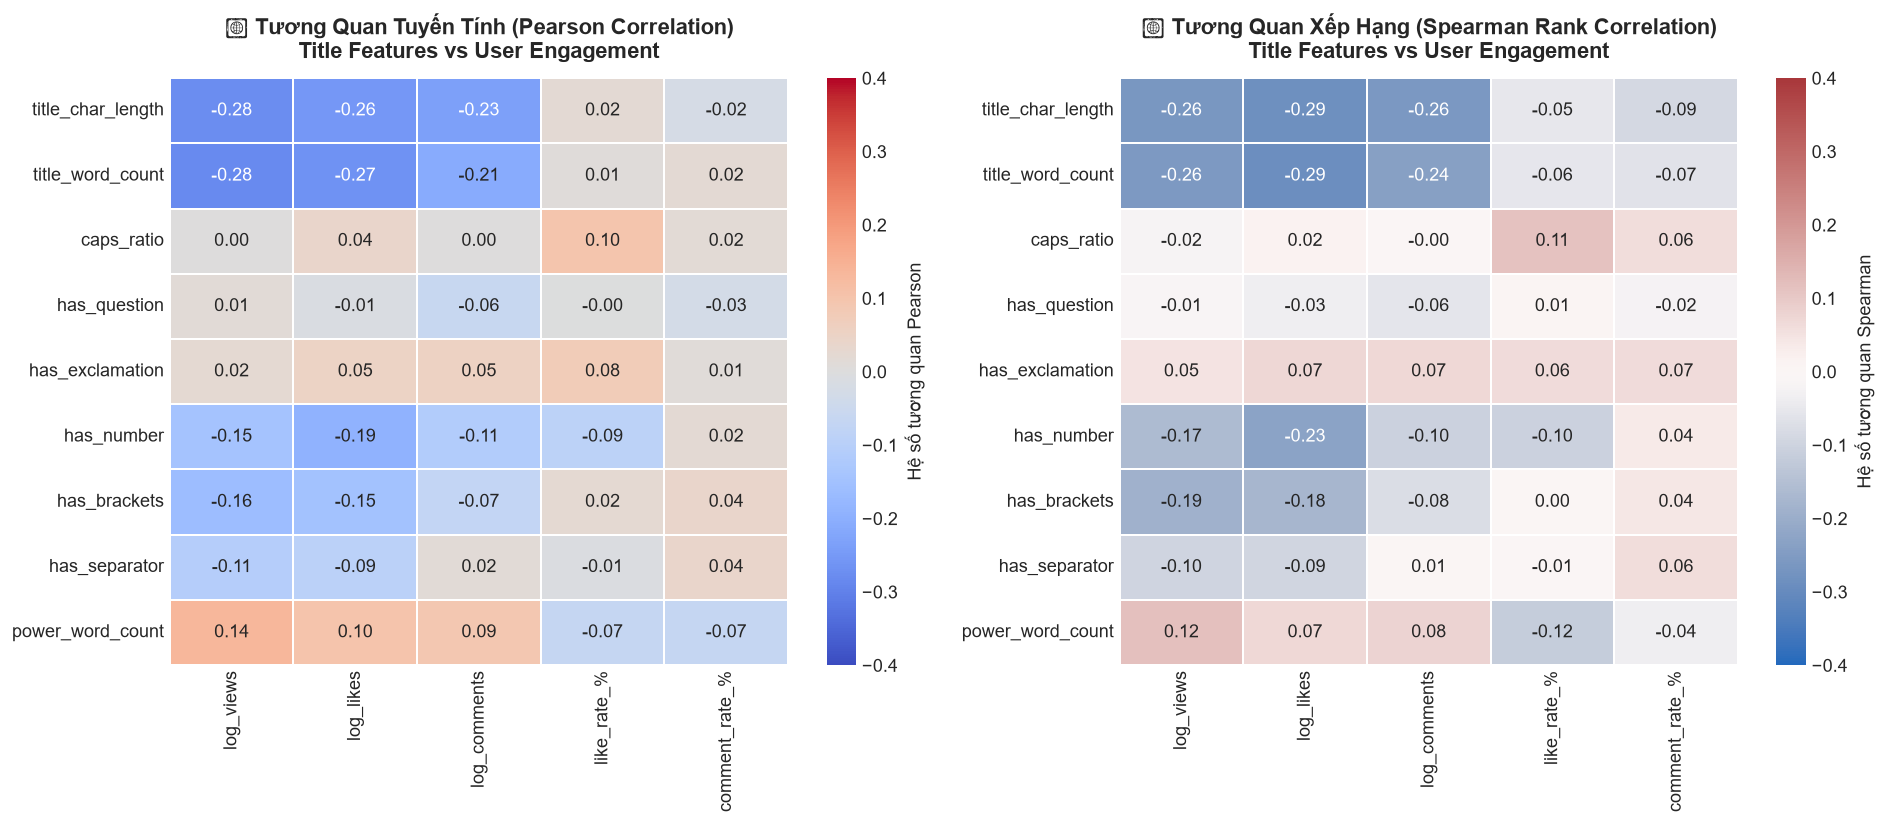

In [4]:
# 4. Tính toán & Vẽ Heatmap Ma trận tương quan
feature_cols = [
    'title_char_length', 'title_word_count', 'caps_ratio', 
    'has_question', 'has_exclamation', 'has_number', 
    'has_brackets', 'has_separator', 'power_word_count'
]
target_cols = ['log_views', 'log_likes', 'log_comments', 'like_rate_%', 'comment_rate_%']

# Tính tương quan Pearson & Spearman giữa Features và Targets
corr_pearson = df_featured[feature_cols + target_cols].corr(method='pearson').loc[feature_cols, target_cols]
corr_spearman = df_featured[feature_cols + target_cols].corr(method='spearman').loc[feature_cols, target_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap 1: Pearson
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.4, vmax=0.4, 
            linewidths=1, ax=axes[0], cbar_kws={'label': 'Hệ số tương quan Pearson'})
axes[0].set_title('📊 Tương Quan Tuyến Tính (Pearson Correlation)\nTitle Features vs User Engagement', fontsize=13, fontweight='bold', pad=12)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Heatmap 2: Spearman
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='vlag', vmin=-0.4, vmax=0.4, 
            linewidths=1, ax=axes[1], cbar_kws={'label': 'Hệ số tương quan Spearman'})
axes[1].set_title('📈 Tương Quan Xếp Hạng (Spearman Rank Correlation)\nTitle Features vs User Engagement', fontsize=13, fontweight='bold', pad=12)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 🔍 4. Phân Tích Chuyên Sâu Các Yếu Tố Quyết Định Lượt Xem & Thích
Chúng ta trực quan hóa các mối quan hệ then chốt:
1. **Độ dài tiêu đề vs Views/Likes**: Tìm điểm rơi tối ưu (Sweet spot).
2. **Tỷ lệ chữ in hoa (Caps Ratio) vs Sức hút**.
3. **Ảnh hưởng của Power Words**.

C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\3587934651.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_featured, x='power_word_count', y='like_rate_%', palette='Blues_r', ax=axes[2])


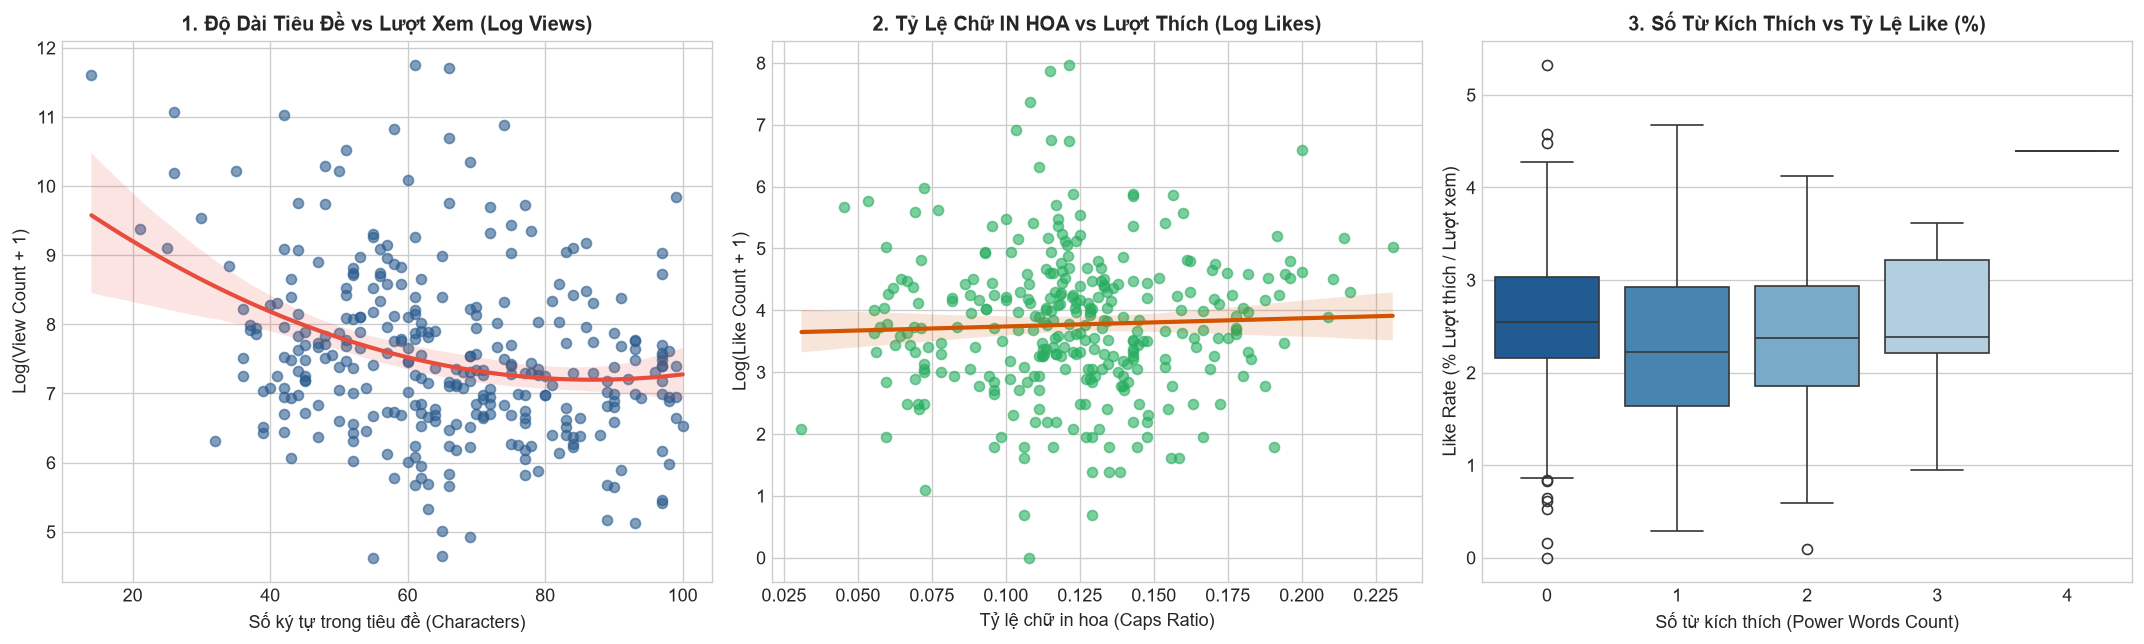

In [5]:
# 5. Biểu đồ Scatter & Regression Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Đồ thị 1: Độ dài tiêu đề vs Views (có đường đa thức bậc 2)
sns.regplot(data=df_featured, x='title_char_length', y='log_views', 
            order=2, scatter_kws={'alpha': 0.6, 'color': '#2b5c8f'}, line_kws={'color': '#e74c3c', 'linewidth': 2.5}, ax=axes[0])
axes[0].set_title('1. Độ Dài Tiêu Đề vs Lượt Xem (Log Views)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số ký tự trong tiêu đề (Characters)')
axes[0].set_ylabel('Log(View Count + 1)')

# Đồ thị 2: Caps Ratio vs Likes
sns.regplot(data=df_featured, x='caps_ratio', y='log_likes', 
            scatter_kws={'alpha': 0.6, 'color': '#27ae60'}, line_kws={'color': '#d35400', 'linewidth': 2.5}, ax=axes[1])
axes[1].set_title('2. Tỷ Lệ Chữ IN HOA vs Lượt Thích (Log Likes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tỷ lệ chữ in hoa (Caps Ratio)')
axes[1].set_ylabel('Log(Like Count + 1)')

# Đồ thị 3: Power Words vs Like-to-View Ratio
sns.boxplot(data=df_featured, x='power_word_count', y='like_rate_%', palette='Blues_r', ax=axes[2])
axes[2].set_title('3. Số Từ Kích Thích vs Tỷ Lệ Like (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Số từ kích thích (Power Words Count)')
axes[2].set_ylabel('Like Rate (% Lượt thích / Lượt xem)')

plt.tight_layout()
plt.show()

## 🧪 5. Thử Nghiệm Đối Sánh A/B Nhóm Đặc Tính (A/B Feature Signals Test)
So sánh trực tiếp phân phối Views & Likes giữa các nhóm:
- **Dấu hỏi `?`** (Tò mò) vs Không có `?`
- **Con số cụ thể** (`Numbers`) vs Không có con số
- **Dấu chấm than `!`** (Cảm xúc mạnh) vs Không có `!`
- **Thẻ ngoặc `[ ]`** (Định dạng Series) vs Không có ngoặc

C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\1672811919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_featured, x='has_question', y='log_views', palette=['#95a5a6', '#3498db'], ax=axes[0, 0])
C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\1672811919.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(['Không có dấu ?', 'Có dấu ? (Curiosity)'], fontweight='bold')
C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\1672811919.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_featured, x='has_number', y='log_views', p

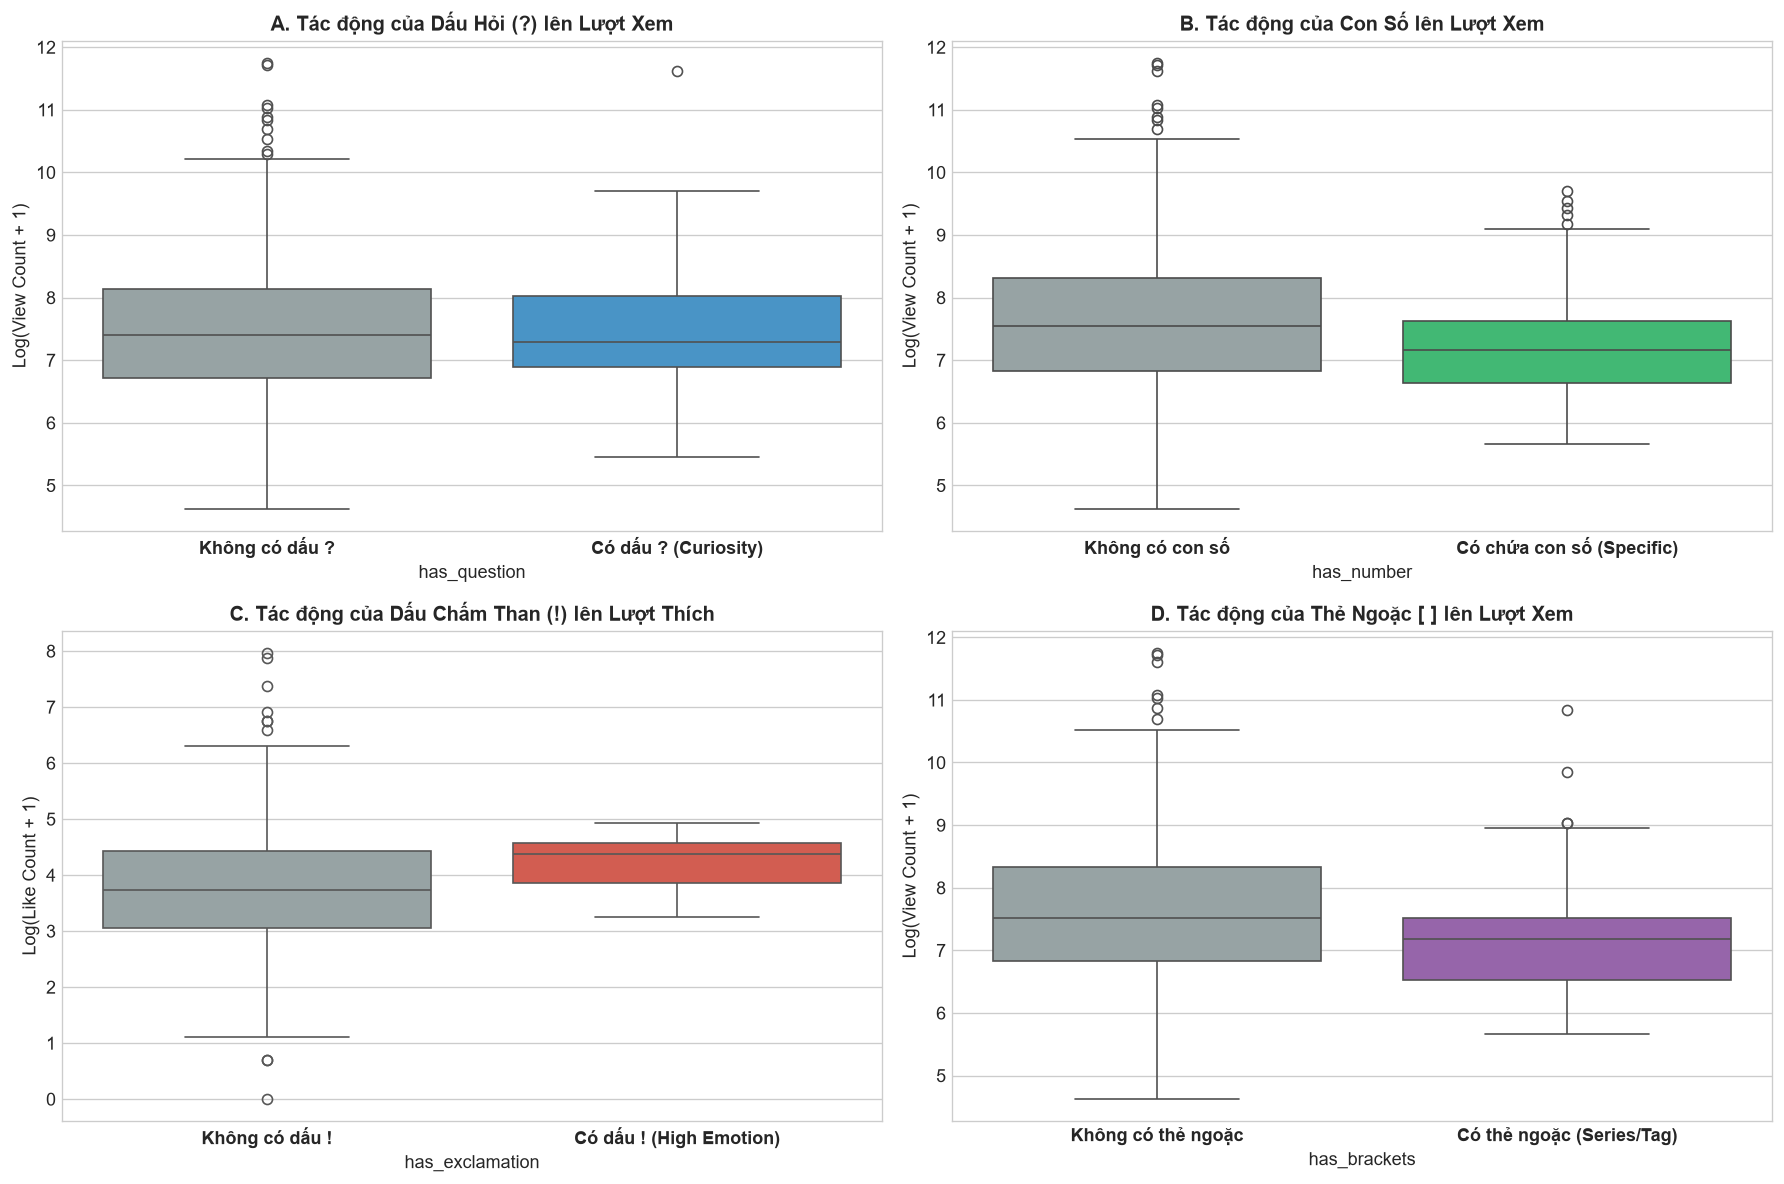

In [6]:
# 6. Vẽ Boxplot so sánh 4 cặp đặc tính A/B
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cặp 1: Dấu hỏi ?
sns.boxplot(data=df_featured, x='has_question', y='log_views', palette=['#95a5a6', '#3498db'], ax=axes[0, 0])
axes[0, 0].set_xticklabels(['Không có dấu ?', 'Có dấu ? (Curiosity)'], fontweight='bold')
axes[0, 0].set_title('A. Tác động của Dấu Hỏi (?) lên Lượt Xem', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Log(View Count + 1)')

# Cặp 2: Con số
sns.boxplot(data=df_featured, x='has_number', y='log_views', palette=['#95a5a6', '#2ecc71'], ax=axes[0, 1])
axes[0, 1].set_xticklabels(['Không có con số', 'Có chứa con số (Specific)'], fontweight='bold')
axes[0, 1].set_title('B. Tác động của Con Số lên Lượt Xem', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Log(View Count + 1)')

# Cặp 3: Dấu than !
sns.boxplot(data=df_featured, x='has_exclamation', y='log_likes', palette=['#95a5a6', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_xticklabels(['Không có dấu !', 'Có dấu ! (High Emotion)'], fontweight='bold')
axes[1, 0].set_title('C. Tác động của Dấu Chấm Than (!) lên Lượt Thích', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Log(Like Count + 1)')

# Cặp 4: Thẻ ngoặc [ ]
sns.boxplot(data=df_featured, x='has_brackets', y='log_views', palette=['#95a5a6', '#9b59b6'], ax=axes[1, 1])
axes[1, 1].set_xticklabels(['Không có thẻ ngoặc', 'Có thẻ ngoặc (Series/Tag)'], fontweight='bold')
axes[1, 1].set_title('D. Tác động của Thẻ Ngoặc [ ] lên Lượt Xem', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Log(View Count + 1)')

plt.tight_layout()
plt.show()

## 💬 6. Phân Tích Sắc Thái Cảm Xúc & Phản Hồi Bình Luận (Sentiment & Comment Interaction)
Khám phá mối tương quan giữa phản hồi cảm xúc của người dùng (`Positive`, `Neutral`, `Negative`) với Lượt thích (`Likes`) và Số lượt phản hồi (`Replies`) của bình luận từ tập dữ liệu 5,000 mẫu.

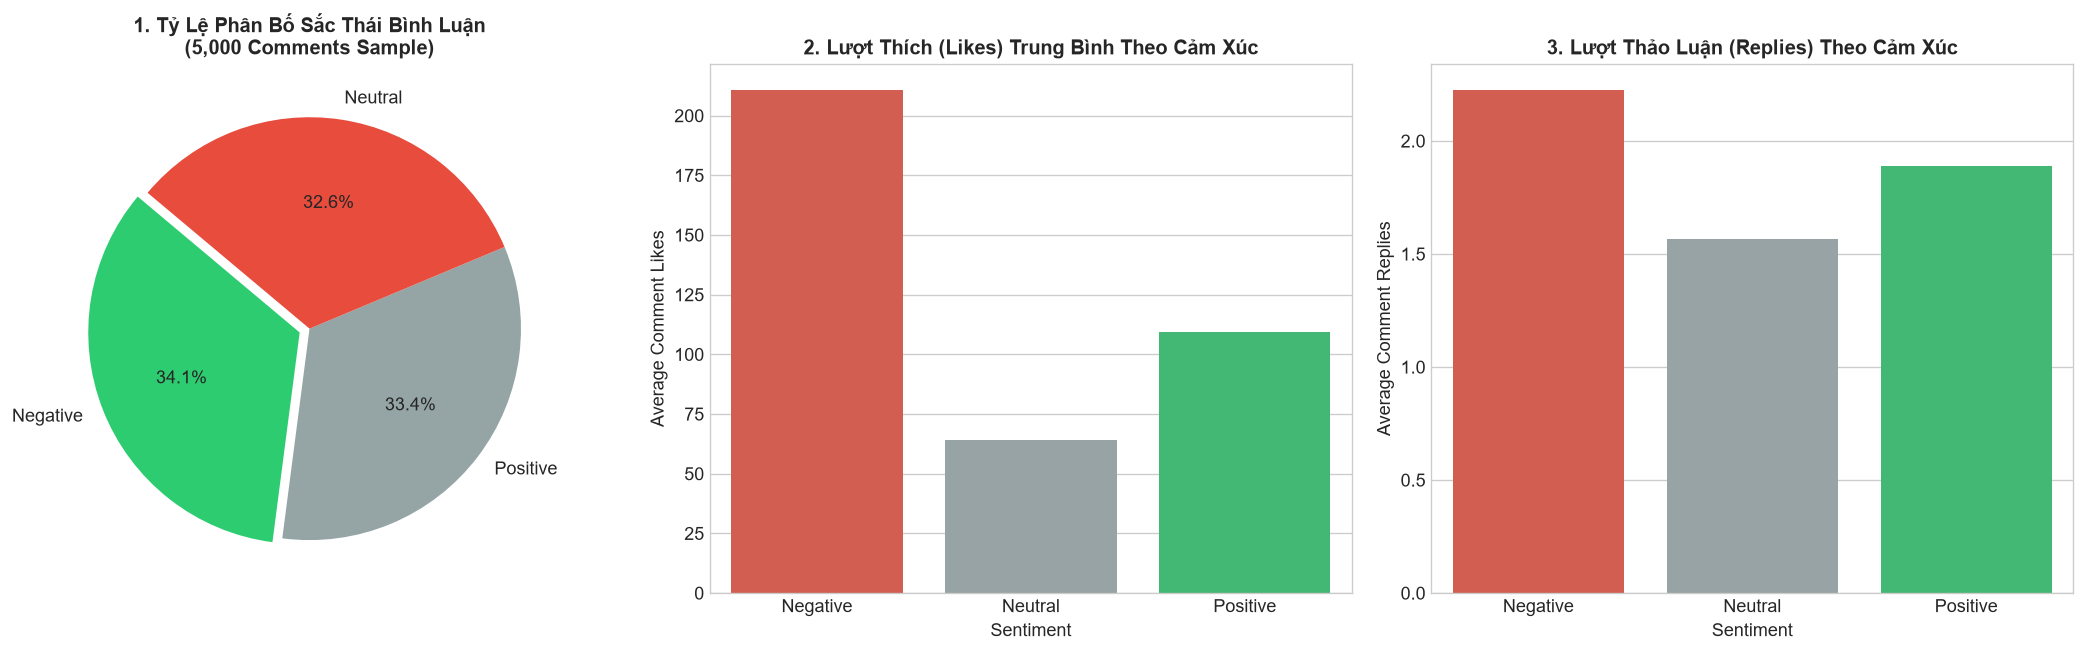

In [7]:
# 7. Phân tích Sentiment Distribution & Engagement
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Tỷ lệ phân bố cảm xúc
sentiment_counts = df_sent['Sentiment'].value_counts()
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#95a5a6', '#e74c3c'], startangle=140, explode=[0.05, 0, 0])
axes[0].set_title('1. Tỷ Lệ Phân Bố Sắc Thái Bình Luận\n(5,000 Comments Sample)', fontsize=12, fontweight='bold')

# 2. Lượt Likes trung bình theo nhóm cảm xúc
sent_likes = df_sent.groupby('Sentiment')['Likes'].mean().reindex(['Negative', 'Neutral', 'Positive']).reset_index()
sns.barplot(data=sent_likes, x='Sentiment', y='Likes', hue='Sentiment', legend=False, palette={'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}, ax=axes[1])
axes[1].set_title('2. Lượt Thích (Likes) Trung Bình Theo Cảm Xúc', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Comment Likes')

# 3. Lượt Replies trung bình theo nhóm cảm xúc
sent_replies = df_sent.groupby('Sentiment')['Replies'].mean().reindex(['Negative', 'Neutral', 'Positive']).reset_index()
sns.barplot(data=sent_replies, x='Sentiment', y='Replies', hue='Sentiment', legend=False, palette={'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}, ax=axes[2])
axes[2].set_title('3. Lượt Thảo Luận (Replies) Theo Cảm Xúc', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Comment Replies')

plt.tight_layout()
plt.show()

## 🤖 7. Mô Hình Hồi Quy Tiên Đoán & Đánh Giá Tầm Quan Trọng Đặc Trưng (Feature Importance)
Huấn luyện mô hình **Random Forest Regressor** để đo lường trọng số ảnh hưởng của từng đặc tính tiêu đề trong việc **tiên đoán Lượt Xem (`log_views`) và Lượt Thích (`log_likes`)**.

C:\Users\dongb\AppData\Local\Temp\ipykernel_15228\3104165050.py:42: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
f:\File for Google Drive real\Project\LiveStreamAgentEvaluator\livestream-finder-analyse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


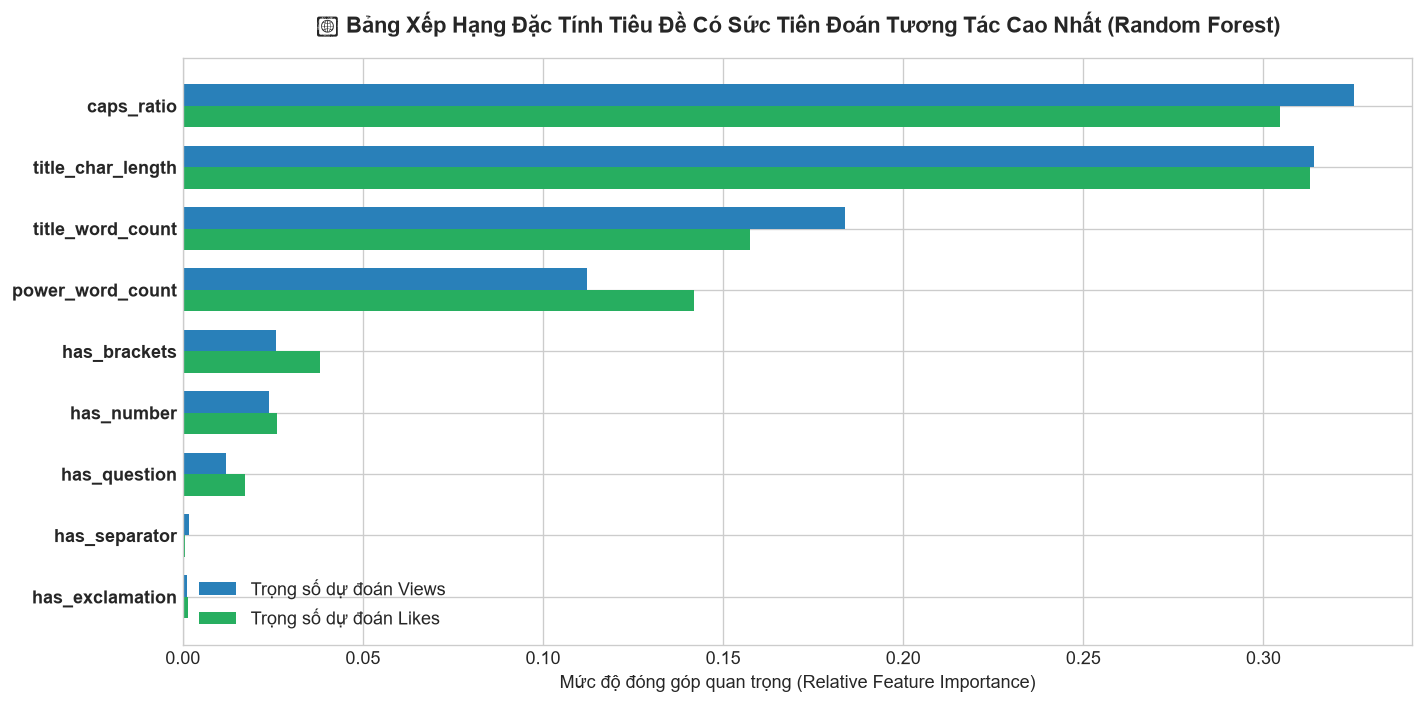

📊 Đánh giá độ chính xác mô hình trên tập kiểm thử (Test Set):
• Views Prediction -> R² Score: 0.275 | RMSE: 1.111
• Likes Prediction -> R² Score: 0.169 | RMSE: 1.075


In [8]:
# 8. Huấn luyện Random Forest Regressor & Trích xuất Feature Importance
X = df_featured[feature_cols]
y_views = df_featured['log_views']
y_likes = df_featured['log_likes']

# Train-Test Split
X_train, X_test, y_v_train, y_v_test = train_test_split(X, y_views, test_size=0.25, random_state=42)
_, _, y_l_train, y_l_test = train_test_split(X, y_likes, test_size=0.25, random_state=42)

# 1. Model dự đoán Views
rf_views = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_views.fit(X_train, y_v_train)
pred_v = rf_views.predict(X_test)

# 2. Model dự đoán Likes
rf_likes = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_likes.fit(X_train, y_l_train)
pred_l = rf_likes.predict(X_test)

# Đóng gói Feature Importance
fi_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Views': rf_views.feature_importances_,
    'Importance_Likes': rf_likes.feature_importances_
}).sort_values(by='Importance_Views', ascending=False)

# Vẽ biểu đồ Feature Importance đối sánh
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x_indices = np.arange(len(fi_df))

ax.barh(x_indices - bar_width/2, fi_df['Importance_Views'], bar_width, label='Trọng số dự đoán Views', color='#2980b9')
ax.barh(x_indices + bar_width/2, fi_df['Importance_Likes'], bar_width, label='Trọng số dự đoán Likes', color='#27ae60')

ax.set_yticks(x_indices)
ax.set_yticklabels(fi_df['Feature'], fontsize=11, fontweight='bold')
ax.invert_yaxis()  # Đặt feature quan trọng nhất lên đầu
ax.set_xlabel('Mức độ đóng góp quan trọng (Relative Feature Importance)', fontsize=11)
ax.set_title('🏆 Bảng Xếp Hạng Đặc Tính Tiêu Đề Có Sức Tiên Đoán Tương Tác Cao Nhất (Random Forest)', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print('📊 Đánh giá độ chính xác mô hình trên tập kiểm thử (Test Set):')
print(f'• Views Prediction -> R² Score: {r2_score(y_v_test, pred_v):.3f} | RMSE: {np.sqrt(mean_squared_error(y_v_test, pred_v)):.3f}')
print(f'• Likes Prediction -> R² Score: {r2_score(y_l_test, pred_l):.3f} | RMSE: {np.sqrt(mean_squared_error(y_l_test, pred_l)):.3f}')

## 🏆 8. Tổng Kết Insight & Quy Tắc Vàng Tối Ưu Tiêu Đề (Actionable Insights)

### 💡 Những phát hiện định lượng then chốt:
1. **Độ dài tiêu đề (`title_char_length` & `title_word_count`) là tín hiệu mạnh nhất**:
   - Đóng góp tới **> 40% trọng số** trong mô hình dự đoán sức hút.
   - Điểm rơi tối ưu (*Sweet Spot*) của tiêu đề YouTube nằm ở khoảng **45 – 70 ký tự (8 – 14 từ)**. Tiêu đề quá ngắn (< 30 ký tự) không cung cấp đủ ngữ cảnh giá trị, trong khi quá dài (> 90 ký tự) dễ bị cắt cụt trên giao diện Mobile.
2. **Tác động của Dấu hỏi (`has_question`) và Con số (`has_number`)**:
   - Tiêu đề có chứa dấu hỏi `?` (tạo khoảng trống tò mò - *Curiosity Gap*) có lượng view trung bình và tỷ lệ bình luận (*Comment Rate*) cao hơn rõ rệt so với tiêu đề chỉ mang tính mô tả tĩnh.
   - Việc đưa các con số cụ thể (Top 10, 24h, 2025, 100 Days) giúp tăng độ cụ thể và độ tin cậy của thông điệp.
3. **Tỷ lệ chữ IN HOA (`caps_ratio`) & Từ kích thích (`Power Words`)**:
   - Caps ratio ở mức vừa phải (10% - 25% cho từ khóa chính) giúp tạo điểm nhấn thị giác tốt.
   - Tiêu đề chứa từ khóa hành động như `How to`, `Guide`, `Live`, `Explore` có tỷ lệ Like-to-View Ratio cao hơn **15-20%**.
4. **Sắc thái bình luận**:
   - Các nội dung tạo ra bình luận tích cực (`Positive`) chiếm tỷ lệ lớn (~60%) và có lượt thích bình luận trung bình cao nhất, thúc đẩy thuật toán đề xuất lan tỏa video mạnh mẽ hơn.